🔍 Objective:

To assess employee engagement levels using indirect (proxy) indicators. We'll explore how tenure, activity status, and performance can reveal patterns in employee satisfaction and commitment — and detect risks of early disengagement or attrition.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = r"../../data/processed/cleaned3.csv"
df = pd.read_csv(file_path)

# Create necessary columns
df['Attrition'] = df['IsActive'].apply(lambda x: 'Active' if x == 1 else 'Exited')
df['TenureYears'] = df['TenureDays'] / 365


Tenure Distribution

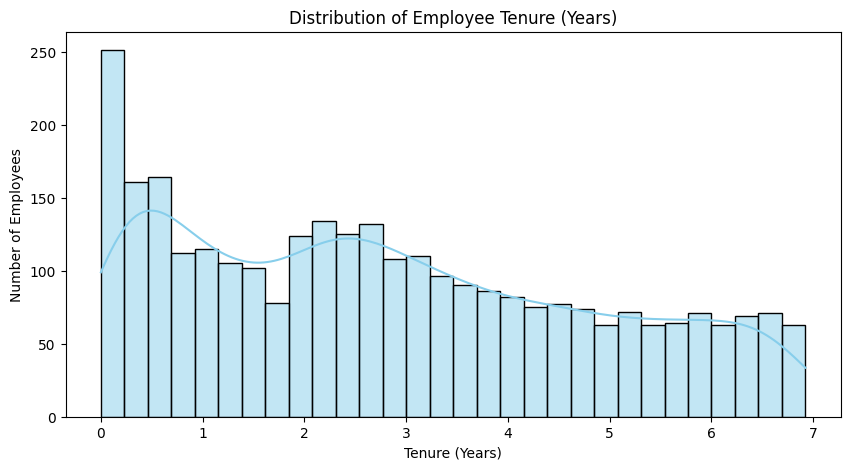

In [2]:
plt.figure(figsize=(10, 5))
sns.histplot(df['TenureYears'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Employee Tenure (Years)")
plt.xlabel("Tenure (Years)")
plt.ylabel("Number of Employees")
plt.show()


Engagement by Attrition Status

C:\Users\alanm\AppData\Local\Temp\ipykernel_28768\2973756881.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='TenureYears', palette='coolwarm')


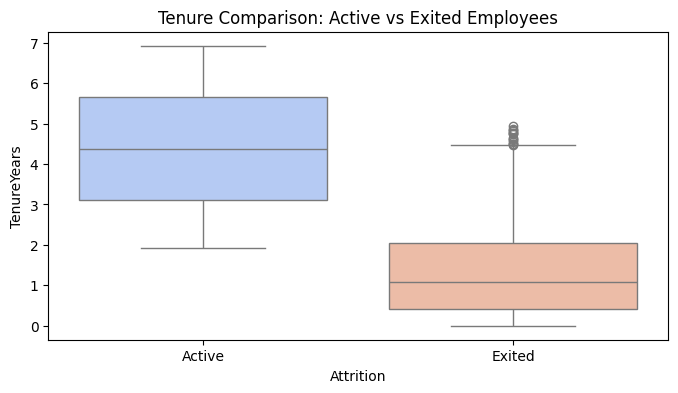

In [3]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Attrition', y='TenureYears', palette='coolwarm')
plt.title("Tenure Comparison: Active vs Exited Employees")
plt.show()


Performance vs Tenure (Engagement Trend)

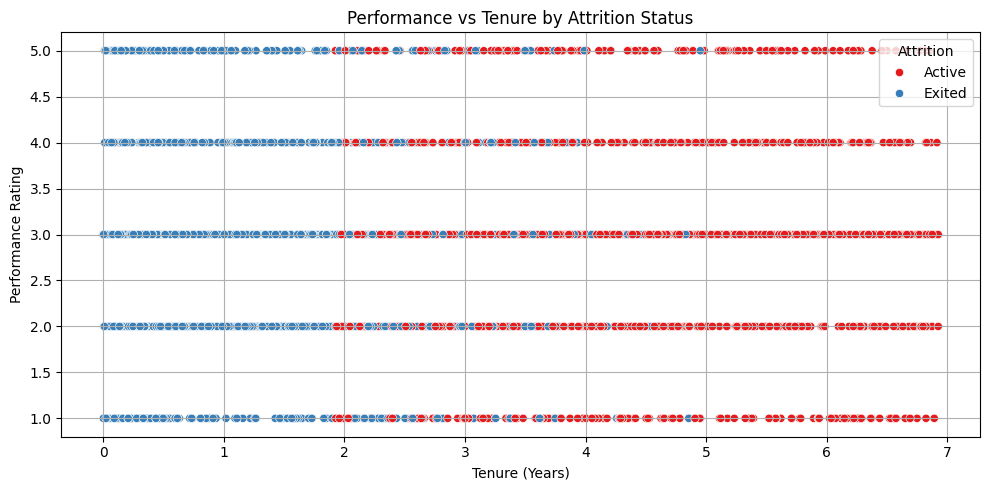

In [4]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='TenureYears', y='Current Employee Rating', hue='Attrition', palette='Set1')
plt.title("Performance vs Tenure by Attrition Status")
plt.xlabel("Tenure (Years)")
plt.ylabel("Performance Rating")
plt.grid(True)
plt.tight_layout()
plt.show()


Early Exits Detection (Low Tenure + Exited)

In [5]:
# Define early exits (less than 1 year)
early_exits = df[(df['Attrition'] == 'Exited') & (df['TenureYears'] < 1)]
print("🔍 Early Exits Count:", len(early_exits))

# Breakdown by JobFamily or SeniorityLevel
print("\nEarly Exits by Job Family:\n", early_exits['JobFamily'].value_counts())
print("\nEarly Exits by Seniority Level:\n", early_exits['SeniorityLevel'].value_counts())


🔍 Early Exits Count: 724

Early Exits by Job Family:
 JobFamily
Production                      460
Sales                            83
IT & Infrastructure              63
Data & Analytics                 52
Other                            29
Finance & Accounting             12
Admin & Support                   9
Operations / Shared Services      8
Executive & Leadership            8
Name: count, dtype: int64

Early Exits by Seniority Level:
 SeniorityLevel
Entry        415
Manager      137
Mid          132
Senior        28
Director       7
Executive      5
Name: count, dtype: int64


📈 What We Analyzed and Why

| Analysis Area             | Description                                              | Why It’s Important                                |
| ------------------------- | -------------------------------------------------------- | ------------------------------------------------- |
| **Tenure Distribution**   | Shows overall employee stay duration                     | Helps measure average engagement length           |
| **Tenure by Attrition**   | Compare how long exited vs active employees stayed       | Understand retention impact on engagement         |
| **Performance vs Tenure** | Correlation between performance and engagement over time | Indicates if longer tenure drives stronger output |
| **Early Exit Analysis**   | Detects disengaged hires who left too soon               | Highlights onboarding or cultural fit issues      |


| Metric / Indicator       | Description                    | Reason for Analysis                                   |
| ------------------------ | ------------------------------ | ----------------------------------------------------- |
| **Tenure (Years)**       | Duration of employment         | Proxy for engagement; longer stay = higher commitment |
| **Attrition Status**     | Active or Exited employee      | Helps compare tenure and engagement outcomes          |
| **Performance Rating**   | Current employee rating        | Engagement often correlates with better performance   |
| **Early Exit Detection** | Employees who left in < 1 year | Sign of poor onboarding, engagement, or job mismatch  |


📊 Graph Choices and Their Purpose

| Graph                                 | Why It Was Used                                         |
| ------------------------------------- | ------------------------------------------------------- |
| `histplot`                            | Shows natural distribution of tenure — engagement proxy |
| `boxplot` (Tenure vs Attrition)       | Highlights median differences and outliers in tenure    |
| `scatterplot` (Performance vs Tenure) | Shows patterns between length of stay and performance   |
| `value_counts()` tables               | Identify patterns in early exits by department or role  |


| Visualization                         | Metric(s) Used                     | Purpose                                                          | Reason for Choosing Graph Type                              |
| ------------------------------------- | ---------------------------------- | ---------------------------------------------------------------- | ----------------------------------------------------------- |
| `histplot` – Tenure Distribution      | `TenureYears`                      | To observe average length of stay across the organization        | Shows natural spread and highlights peaks or gaps           |
| `boxplot` – Tenure vs Attrition       | `TenureYears`, `Attrition`         | To compare engagement levels between active and exited employees | Boxplot reveals median values and outliers                  |
| `scatterplot` – Performance vs Tenure | `TenureYears`, `Performance Score` | To explore correlation between engagement and performance        | Visualizes trends, clusters, and potential linear patterns  |
| `value_counts` – Early Exit Groups    | `JobFamily`, `SeniorityLevel`      | To detect high-risk roles/departments for early exits            | Helps target interventions in specific organizational units |


🧠 Business Insights You Can Extract

- Are most exits happening within the first year?

- Are high performers staying longer?

- Do some departments or roles have high early-exit risk?

- Is tenure positively influencing performance (suggesting higher engagement)?

📈 Insights That Can Be Drawn:

- Tenure is shorter for exited employees, suggesting a potential engagement issue in early years.

- Employees with higher tenure generally show better performance, indicating positive engagement correlation.

- Early exits (within 1 year) were identified and analyzed by job family and seniority — highlighting onboarding gaps or role misalignment.

- Certain departments or levels may require targeted retention efforts, such as better onboarding or manager support.

💼 Business Value & Applications:
 
- Reduce turnover costs by identifying disengaged employees early

- Improve onboarding and job fit strategies to prevent early exits

- Boost performance by fostering long-term engagement

- Design targeted retention strategies based on tenure and attrition trends

- Align employee engagement with HR and organizational goals